# Import Libraries

In [1]:
import os
import re
import string
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


# Load the Dataset

In [2]:
def generate_synthetic_dataset(n_per_class=600, seed=RANDOM_STATE):
    """Generates a synthetic fake/real news dataset for demonstration purposes.
    Replace this with a real dataset (e.g. Kaggle's Fake and Real News Dataset) for actual results."""
    rng = np.random.RandomState(seed)

    real_templates = [
        "The government announced a new policy on {topic} after months of discussion with experts.",
        "Scientists at a leading university published a peer-reviewed study on {topic} this week.",
        "Officials confirmed that {topic} figures were released following an audited report.",
        "The central bank stated that {topic} trends remain in line with economic forecasts.",
        "A press briefing was held to clarify recent developments regarding {topic}.",
        "According to official data, {topic} has shown a steady and well documented trend this quarter.",
    ]
    fake_templates = [
        "You won't believe what they are hiding about {topic}, shocking secret exposed!!!",
        "Doctors HATE this one trick that instantly fixes {topic} forever, click now.",
        "Anonymous insider reveals {topic} conspiracy that the mainstream media refuses to show you.",
        "BREAKING: {topic} scandal covered up by elites, share before it gets deleted.",
        "Miracle cure for {topic} that Big Pharma does not want you to know about.",
        "Leaked documents allegedly prove {topic} is a massive hoax, spread the truth now.",
    ]
    topics = [
        'the economy', 'climate policy', 'vaccine research', 'election results',
        'the housing market', 'a new technology', 'public health', 'trade agreements',
        'space exploration', 'local elections', 'a celebrity scandal', 'a new law'
    ]

    rows = []
    for _ in range(n_per_class):
        t = rng.choice(topics)
        template = rng.choice(real_templates)
        rows.append({'text': template.format(topic=t), 'label': 'REAL'})
    for _ in range(n_per_class):
        t = rng.choice(topics)
        template = rng.choice(fake_templates)
        rows.append({'text': template.format(topic=t), 'label': 'FAKE'})

    df = pd.DataFrame(rows).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df


if os.path.exists('news.csv'):
    df = pd.read_csv('news.csv')
    df = df[['text', 'label']].dropna()
    print('Loaded real dataset from news.csv')

elif os.path.exists('Fake.csv') and os.path.exists('True.csv'):
    df_fake = pd.read_csv('Fake.csv')
    df_true = pd.read_csv('True.csv')
    df_fake['label'] = 'FAKE'
    df_true['label'] = 'REAL'
    df = pd.concat([df_fake, df_true], axis=0, ignore_index=True)
    if 'title' in df.columns and 'text' in df.columns:
        df['text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
    df = df[['text', 'label']].dropna()
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    print('Loaded real dataset from Fake.csv / True.csv')

else:
    df = generate_synthetic_dataset()
    print('No dataset file found - generated a synthetic dataset for demonstration.')

print('Dataset shape:', df.shape)
df.head()

No dataset file found - generated a synthetic dataset for demonstration.
Dataset shape: (1200, 2)


,text,label
0,BREAKING: the housing market scandal covered u...,FAKE
1,Anonymous insider reveals trade agreements con...,FAKE
2,Officials confirmed that a new law figures wer...,REAL
3,A press briefing was held to clarify recent de...,REAL
4,The central bank stated that space exploration...,REAL


# Exploratory Data Analysis (EDA)

In [3]:
print('Missing values:\n', df.isnull().sum())
print('\nLabel distribution:\n', df['label'].value_counts())

Missing values:
 text     0
label    0
dtype: int64

Label distribution:
 label
FAKE    600
REAL    600
Name: count, dtype: int64


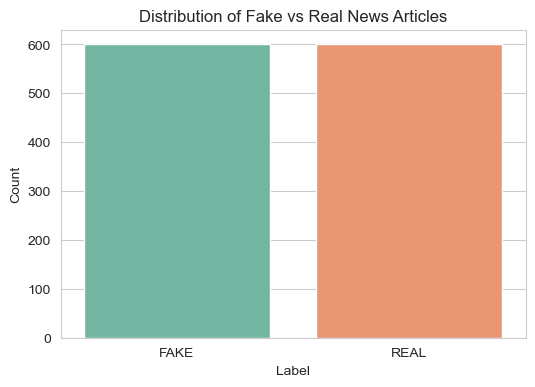

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', hue='label', palette='Set2', legend=False)
plt.title('Distribution of Fake vs Real News Articles')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

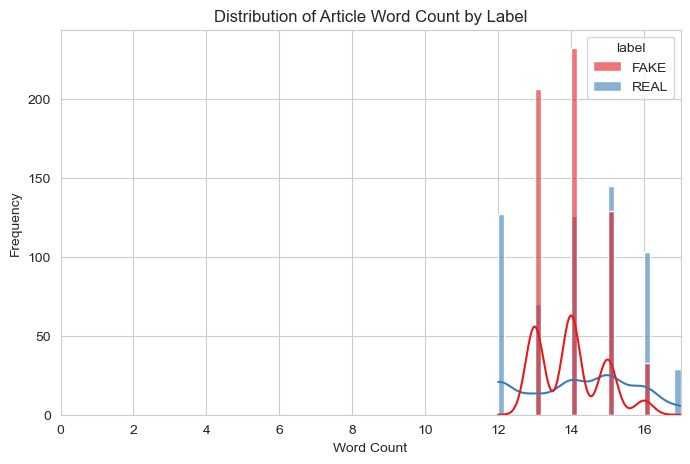

In [5]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='text_length', hue='label', bins=30, kde=True, palette='Set1', alpha=0.6)
plt.title('Distribution of Article Word Count by Label')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.xlim(0, df['text_length'].quantile(0.99))
plt.show()

# Text Preprocessing (NLP Techniques)

In [6]:
stemmer = PorterStemmer()
STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()                                   # lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)        # remove URLs
    text = re.sub(r'<.*?>+', '', text)                          # remove HTML tags
    text = re.sub(r'\[.*?\]', '', text)                         # remove text in square brackets
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)  # remove punctuation
    text = re.sub(r'\w*\d\w*', '', text)                        # remove words containing digits
    text = re.sub(r'\n', ' ', text)                             # remove newlines
    text = re.sub(r'\s+', ' ', text).strip()                    # collapse whitespace

    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in STOPWORDS and len(word) > 1]
    return ' '.join(tokens)


df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,BREAKING: the housing market scandal covered u...,break hous market scandal cover elit share get...
1,Anonymous insider reveals trade agreements con...,anonym insid reveal trade agreement conspiraci...
2,Officials confirmed that a new law figures wer...,offici confirm new law figur releas follow aud...
3,A press briefing was held to clarify recent de...,press brief held clarifi recent develop regard...
4,The central bank stated that space exploration...,central bank state space explor trend remain l...


# Train / Test Split

In [7]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing samples: ', X_test.shape[0])

Training samples: 960
Testing samples:  240


# Feature Extraction with TF-IDF

In [8]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF training matrix shape:', X_train_tfidf.shape)
print('TF-IDF testing matrix shape: ', X_test_tfidf.shape)

TF-IDF training matrix shape: (960, 443)
TF-IDF testing matrix shape:  (240, 443)


# Model Training

In [9]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_tfidf, y_train)

print('Both models trained successfully.')

Both models trained successfully.


# Model Evaluation - Accuracy & F1-Score

--- Naive Bayes ---
Accuracy : 1.0000
F1-Score : 1.0000
Precision: 1.0000
Recall   : 1.0000

Classification Report:
               precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00       120
        REAL       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



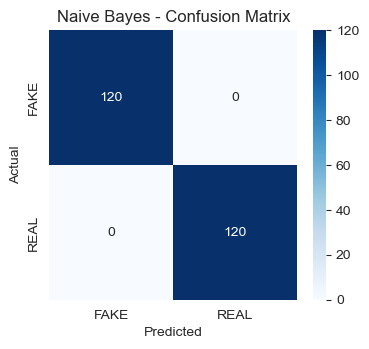

In [10]:
def evaluate_model(model, name, X_test_vec, y_test):
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label='FAKE')
    precision = precision_score(y_test, y_pred, pos_label='FAKE')
    recall = recall_score(y_test, y_pred, pos_label='FAKE')

    print(f'--- {name} ---')
    print(f'Accuracy : {acc:.4f}')
    print(f'F1-Score : {f1:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print('\nClassification Report:\n', classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return {'model': name, 'accuracy': acc, 'f1_score': f1, 'precision': precision, 'recall': recall}


nb_results = evaluate_model(nb_model, 'Naive Bayes', X_test_tfidf, y_test)

--- Logistic Regression ---
Accuracy : 1.0000
F1-Score : 1.0000
Precision: 1.0000
Recall   : 1.0000

Classification Report:
               precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00       120
        REAL       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



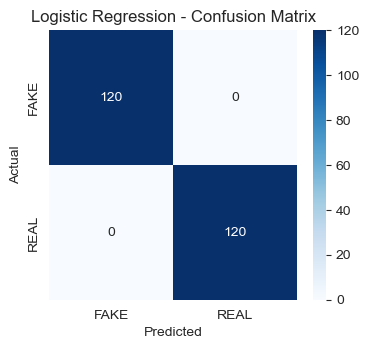

In [11]:
lr_results = evaluate_model(lr_model, 'Logistic Regression', X_test_tfidf, y_test)

# Model Comparison

,accuracy,f1_score,precision,recall
model,,,,
Naive Bayes,1.0,1.0,1.0,1.0
Logistic Regression,1.0,1.0,1.0,1.0


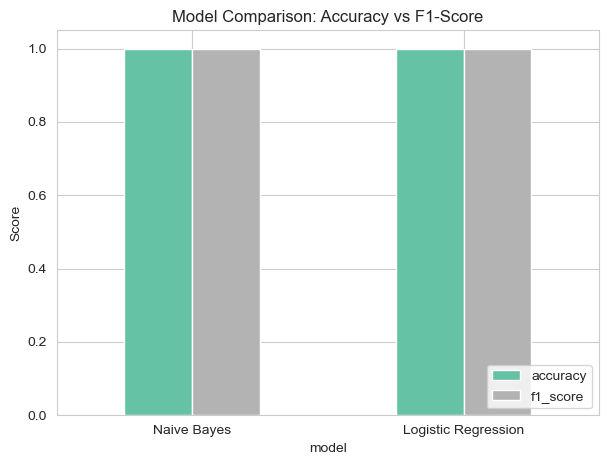

Best model based on F1-Score: Naive Bayes


In [12]:
results_df = pd.DataFrame([nb_results, lr_results]).set_index('model')
display(results_df)

results_df[['accuracy', 'f1_score']].plot(kind='bar', figsize=(7, 5), colormap='Set2')
plt.title('Model Comparison: Accuracy vs F1-Score')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.show()

best_model_name = results_df['f1_score'].idxmax()
best_model = nb_model if best_model_name == 'Naive Bayes' else lr_model
print(f'Best model based on F1-Score: {best_model_name}')

# Cross-Validation (Robustness Check)

In [13]:
X_full_tfidf = tfidf.transform(df['clean_text'])
y_full = df['label']

cv_scores = cross_val_score(best_model, X_full_tfidf, y_full, cv=5, scoring='f1_macro')

print('Cross-validation F1 (macro) scores:', np.round(cv_scores, 4))
print(f'Mean F1 (macro): {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}')

Cross-validation F1 (macro) scores: [1. 1. 1. 1. 1.]
Mean F1 (macro): 1.0000  |  Std: 0.0000


# Test on Custom / Unseen Examples

In [14]:
def predict_news(text, model=best_model, vectorizer=tfidf):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0] if hasattr(model, 'predict_proba') else None
    result = {'prediction': pred}
    if proba is not None:
        classes = model.classes_
        result['confidence'] = dict(zip(classes, np.round(proba, 3)))
    return result


sample_1 = 'Scientists confirm new economic growth figures after a peer-reviewed government audit.'
sample_2 = 'SHOCKING secret they dont want you to know, doctors hate this miracle cure, share now!!!'

print('Sample 1:', predict_news(sample_1))
print('Sample 2:', predict_news(sample_2))

Sample 1: {'prediction': np.str_('REAL'), 'confidence': {np.str_('FAKE'): np.float64(0.0), np.str_('REAL'): np.float64(1.0)}}
Sample 2: {'prediction': np.str_('FAKE'), 'confidence': {np.str_('FAKE'): np.float64(1.0), np.str_('REAL'): np.float64(0.0)}}
